# Análise Exploratória — Heart Disease (UCI)

Objetivo: entender os dados antes de modelar.
- Volume e estrutura
- Qualidade (valores faltantes, tipos)
- Distribuição das variáveis e do alvo

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("Bibliotecas importadas")
print("pandas:", pd.__version__)

Bibliotecas importadas
pandas: 3.0.5


In [2]:
from ucimlrepo import fetch_ucirepo

# Baixa o dataset Heart Disease do repositório UCI (id=45)
heart_disease = fetch_ucirepo(id=45)

# Separa as variáveis preditoras (X) e o alvo (y)
X = heart_disease.data.features
y = heart_disease.data.targets

print("Download concluído")
print("Formato de X (linhas, colunas):", X.shape)
print("Formato de y (linhas, colunas):", y.shape)

Download concluído
Formato de X (linhas, colunas): (303, 13)
Formato de y (linhas, colunas): (303, 1)


In [3]:
# Mostra as 5 primeiras linhas das variáveis preditoras
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [4]:
#informações da matriz
X.info()
X.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

In [5]:
# Ver os valores únicos do alvo e quantas vezes cada um aparece
print("Formato de y:", y.shape)
print("\nContagem de cada valor no alvo:")
print(y.value_counts())

Formato de y: (303, 1)

Contagem de cada valor no alvo:
num
0      164
1       55
2       36
3       35
4       13
Name: count, dtype: int64


In [6]:
# Transformar o alvo multiclasse (0-4) em binário (0 = sem doença, 1 = com doença)
# Qualquer valor >= 1 vira 1
y_binario = (y['num'] >= 1).astype(int)

# Conferir o resultado
print("Distribuição do alvo binário:")
print(y_binario.value_counts())
print("\nProporção:")
print(y_binario.value_counts(normalize=True))

Distribuição do alvo binário:
num
0    164
1    139
Name: count, dtype: int64

Proporção:
num
0    0.541254
1    0.458746
Name: proportion, dtype: float64


In [7]:
#Descreve informações detalhadas do DataFrame

X.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


# Coleta de dados até aqui 

Verificamos o dataframe retornado pelo UCI. São 303 Pacientes que serão verificados afim de buscar problemas do coração. Vimos que faltam 6 dados: 4 em ca e 2 em thal. Já temos o describe dos dados. Iremos fazer uma análise visual das variáveis, e separar os dados para treino/teste


In [8]:
#Fazendo o EDA

X_eda = X.copy()
X_eda["doente"] = y_binario
X_eda.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,doente
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


<Axes: xlabel='oldpeak', ylabel='Count'>

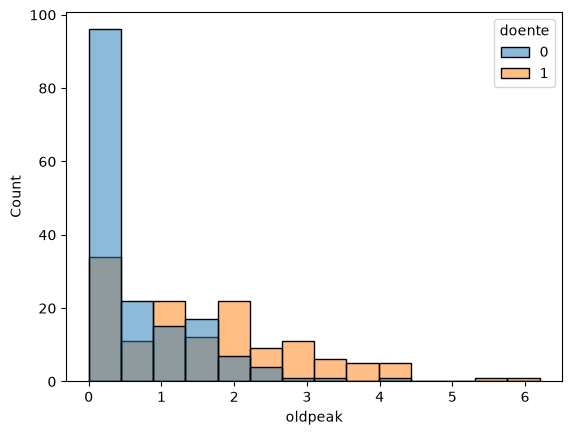

In [9]:
#Fazer histograma

sns.histplot(data=X_eda, x='oldpeak', hue="doente")

Feito a análise gráfica, vou verificado alguns dados de algumas variáveis. age >, thalach <, oldpeak >, risco de doença >


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binario,
    test_size = 0.2,
    random_state = 42,
    stratify = y_binario
)

print("train", X_train.shape)
print("test", X_test.shape)

train (242, 13)
test (61, 13)
